# Веб-скрапинг

## Магическая установка библиотек

In [ ]:
# Убедитесь, что вотэтовотвсё установлено
import urllib, requests, socket, re, lxml, io, bs4, sqlite3, pandas, sqlalchemy

In [ ]:
#!pip install lxml bs4 scrapy pandas sqlalchemy

## Как работает Интернет?

Два основных концепта:
- пакеты
- протоколы

**Пакет** - малый фрагмент большого сообщения. Каждый пакет несет полезные данные и информацию об этих данных (aka *заголовок*), благодаря которой получатель пакета понимает что с ним делать.

Пересылка данных выполняется следующим образом:
- данные разбиваются на набор пакетов
- пакеты преобразуются в биты (набор 0 и 1) и отправляются в сеть
- пакеты перемещаются по сети с помощью маршрутизирующих устройств (роутеры, свитчи)
- пакеты попадают на целевой компьютер
- целевой компьютер с помощью заголовков собирает из пакетов исходные данные

Пакеты передаются по сети с помощью **коммутации пакетов** (packet switching). Промежуточные роутеры и свитчи могут обрабатывать пакеты независимо, без учета откуда они пришли и куда направляются. Это приводит к тому, что ни одно соединение не является более приоритетным - в итоге это соединение не будет занимать единолично сетевое устройство.

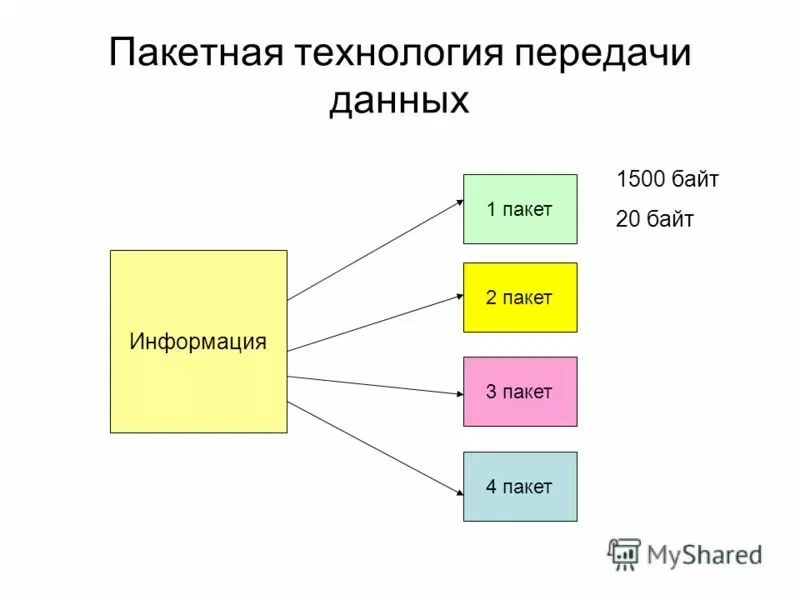

Соединение двух компьютеров, у которых может быть разное "железо" и разные программы - одна из основных проблем, появившихся на заре Интернета. Необходимы правила передачи информации, которые были бы универсальны для всех компьютеров.


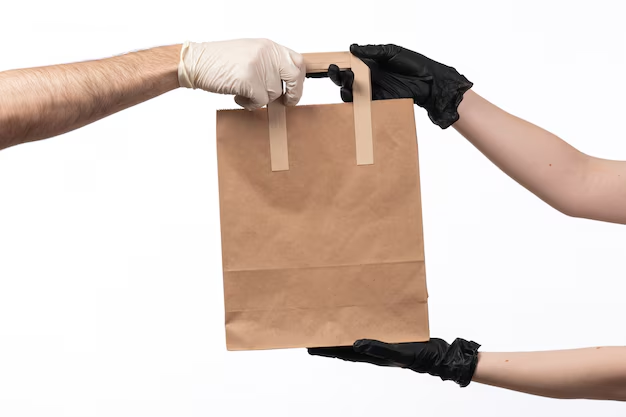

Эту проблемы удалось разрешить с помощью введения **протоколов** - стандатизированного способа выполнения определенных действий и форматирования данных, чтобы устройства могли друг друга понимать.

Существует огромное количество протоколов:
- для передачи пакетов между устройствами внутри одной сети (Ethernet)
- для передачи пакетов между сетями (IP)
- для гарантированной передачи пакетов в нужном порядке (TCP)
- для форматирования данных для вебсайтов и приложений (HTTP)

Помимо этих основных протоколов существует огромное количество других протоколов, которые используются для разных целей - маршрутизации, тестирования, шифрования и т.д.

### Пример - подключение к colab

Для отображения этой страницы компьютеры обмениваются тысячами пакетов, которые передаются по кабелям и волнам через роутеры и свитчи. Ваш компьютер получает эти пакеты и передает их в браузер, а затем браузер интерпретирует данные из пакетов, чтобы отобразить этот текст.

Какие шаги вовлечены в этот процесс:
- **Запрос в браузере.** Вы вбиваете URI ресурса, который вам нужен:
    
    `<схема>:[//[<логин>[:<пароль>]@]<хост>[:<порт>]][/<URL‐путь>][?<параметры>][#<якорь>]`  
- **DNS запрос.** Для идентификации компьютеров в сети используются IP адреса вида `127.0.0.1`. Эти адреса удобны для машин, но неудобны для людей (цифры неудобно запоминать) - намного удобнее использовать *доменные имена*, например, `google.com`. Чтобы сопоставлять IP адреса и доменные имена используются службы доменных имен (*Domain Name Service*, *DNS*). - они помогают по доменному имени получать IP адрес компьютера (не только это, но опустим).
- **TCP рукопожатие.** Браузер устанавлиевает соединение с этим IP адресом.
- **TLS рукопожатие.** Браузер также устанавливает шифрование с сервером, чтобы никто еще не смог прочитать данные из пакетов.
- **HTTP запрос.** Браузер запрашивает содержимое этой веб-страницы.
- **HTTP ответ.** Сервер отдает содержимое веб-страницы в виде HTML, CSS и JavaScript кода, разбитых на набор пакетов. Как только бразуер получает пакеты и проверяет их содержимое, он интерпретирует их как веб-страница, которую вы видите.

Весь процесс занимает 1-2 секунды.

**Вопрос:** Что такое URI??

**URI** — символьная строка, позволяющая идентифицировать какой-либо ресурс: документ, изображение, файл, службу, ящик электронной почты

**URL** — это URI, который, помимо идентификации ресурса, предоставляет ещё и информацию о местонахождении этого ресурса

### HTML



**HTML** (HyperText Markup Language) -- язык разметки, который используется для web-страниц.

Это механизм для получения структурного текста, который понимают браузеры.

Структура в тексте задаётся вложенными тегами, теги определяют то, как текст будет показан (отрендерен).

Это тег: `<тег>`, теги бывают открывающими (`<тег>`) и закрывающими (`</тег>`).

Пример HTML-разметки:

```html
<!DOCTYPE html>
<html>
   <head>
      <meta charset="utf-8" />
      <title>HTML Document</title>
   </head>
   <body>
      <p> <!-- p -- это параграф, а в такие странные скобки заключается комментарий -->
         <b>
            Этот текст будет полужирным, <i>а этот — ещё и курсивным</i>.
         </b>
      </p>
   </body>
</html>
```

Так он выглядит после рендеринга:

<!DOCTYPE html>
<html>
   <head>
      <meta charset="utf-8" />
      <title>HTML Document</title>
   </head>
   <body>
      <p> <!-- p -- это параграф, а в такие странные скобки заключается комментарий -->
         <b>
            Этот текст будет полужирным, <i>а этот — ещё и курсивным</i>.
         </b>
      </p>
   </body>
</html>

Видно, что HTML-разметка имеет древовидную структуру - каждый тег (вершина дерева) имеет 0 (тогда это лист дерева) или больше (тогда это внутренняя вершина) вложенных в него тегов.

Значит, чтобы доставать из HTML какую-то информацию, можно использовать его структуру.

Мы этим займёмся чуть позже.

А ещё у тегов бывают **атрибуты**:

```html
<a href="http://example.com">Ссылка на example.com</a>
```
Отрендерим этот кусок:
<a href="http://example.com">Ссылка на example.com</a>

А этот текст (безусловно, имеющий структуру), был написан с помощью другого языка разметки -- **Markdown**. [Руководство](https://paulradzkov.com/2014/markdown_cheatsheet/)

**P.S.**
На самом деле, такую же структуру имеет и формат XML (другой язык разметки).

Формально, HTML -- это более стандартизированное подмножество XML.

### HTTP

**HTTP** (HyperText Transfer Protocol) - протокол передачи гипертекста. У него есть много разных версий, наиболее популярная HTTP/2

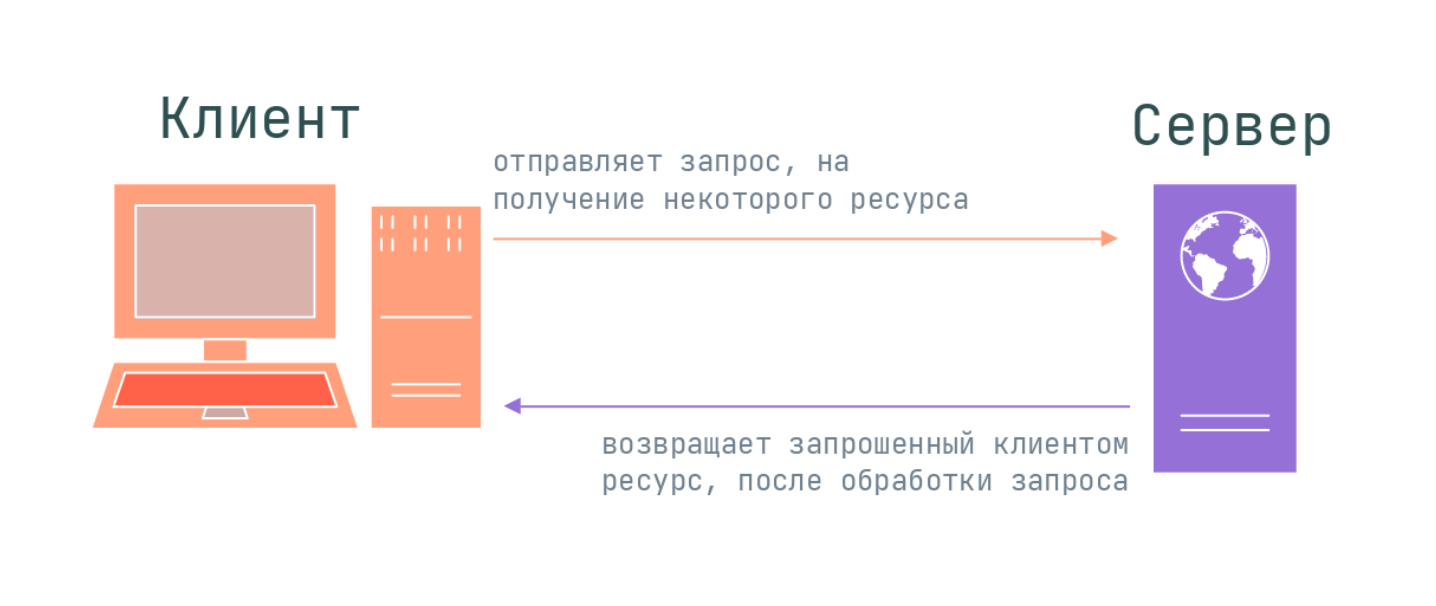

#### Из чего состоит запрос

**Осторожно, может кокнуть!**

Чтобы получить данные, клиент делает запрос (*HTTP Request*) на сервер. В запросе должны быть 4 части:
1. **Starting line** -- определяет тип сообщения;
2. **HTTP-заголовки (HTTP Headers)** -- несколько строчек текста в определенном формате, которые либо уточняют запрос, либо описывают содержимое тела сообщения;
3. **Пустая строка**, которая сообщает, что все метаданные для конкретного запроса или ответа были отправлены.
4. Опциональное **тело сообщения**, которое содержит данные, связанные с запросом, либо документ (например HTML-страницу), передаваемый в  ответе

Ответное сообщение (*HTTP Response*) от сервера имеет такую же структуру.

##### Starting line

1. **Метод HTTP-запроса**
  *   **GET**

    сообщает серверу, что пользователь хочет получить некоторые данные
  *  **POST**
    
    некоторые данные должны быть помещены на сервер

2. **Цель запроса**  
  URL
3. **Версия используемого протокола**

  (либо HTTP/1.1, либо HTTP/2), которая определяет структуру следующих за стартовой строкой данных.

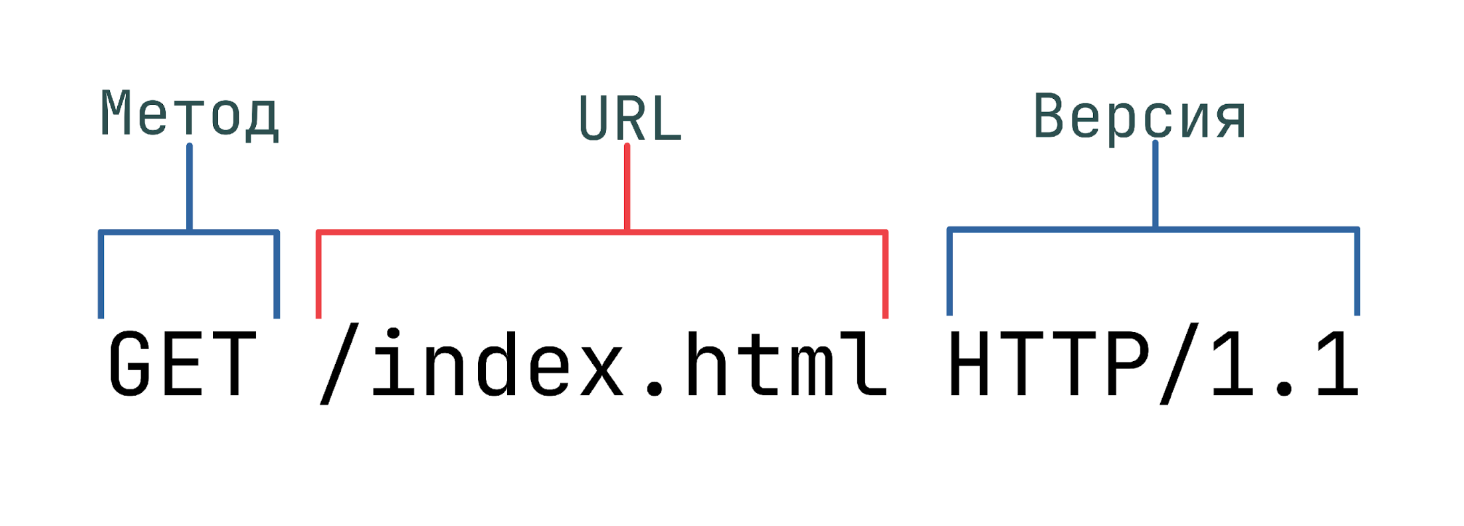

##### Headers

Строка формата **«Имя-Заголовок:Значение»**, с двоеточием(:) в качестве разделителя - всякая информация

##### Body

Не у каждого HTTP-метода предполагается наличие тела. Так, например, методам вроде GET, HEAD, DELETE, OPTIONS обычно не требуется тело

##### Пример

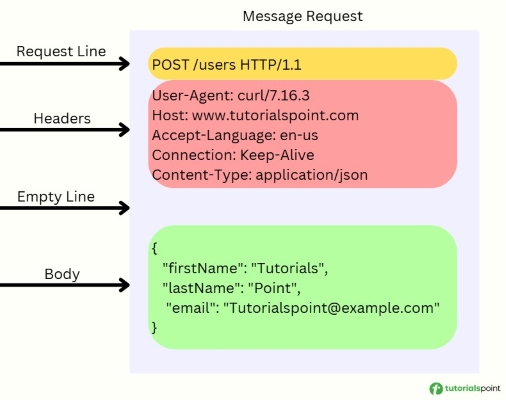

### Из чего состоит ответ

1. Строка статуса (Status line)
2. Response Headers - уточняют ответ
3. Пустая строка
5. Тело ответа

##### Status line

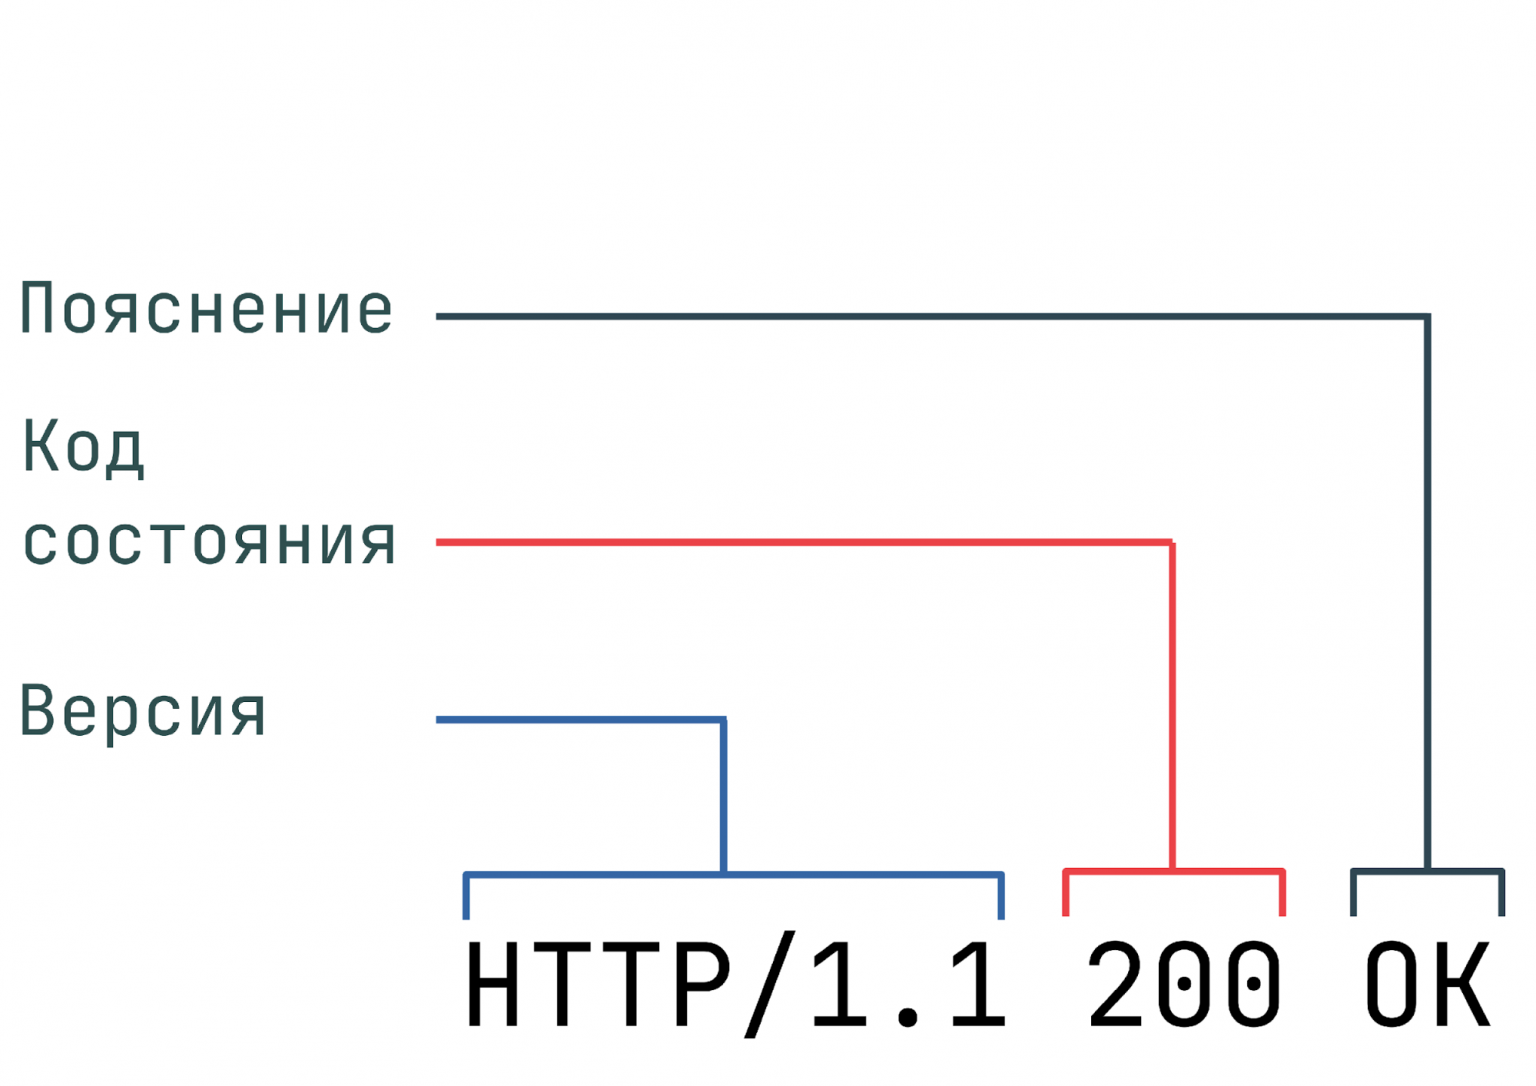

Коды состояния HTTP используются для того, чтобы сообщить клиенту статус их запроса. HTTP-сервер может вернуть код, принадлежащий одной из пяти категорий кодов состояния:

| Категория | Описание                                                                 |
|-----------|-------------------------------------------------------------------------|
| **1xx**   | Коды из данной категории носят исключительно информативный характер и никак не влияют на обработку запроса. |
| **2xx**   | Коды состояния из этой категории возвращаются в случае успешной обработки клиентского запроса. |
| **3xx**   | Эта категория содержит коды, которые возвращаются, если серверу нужно перенаправить клиента. |
| **4xx**   | Коды данной категории означают, что на стороне клиента был отправлен некорректный запрос.<br><br>Например, клиент в запросе указал не поддерживаемый метод или обратился к ресурсу, к которому у него нет доступа. |
| **5xx**   | Ответ с кодами из этой категории приходит, если на стороне сервера возникла ошибка. |

Посмотрим самые распространенные ответы

| Код состояния | Описание |
|---------------|-----------|
| **200 OK** | Возвращается в случае успешной обработки запроса, при этом тело ответа обычно содержит запрошенный ресурс. |
| **302 Found** | Перенаправляет клиента на другой URL. <br><br>Например, данный код может прийти, если клиент успешно прошел процедуру аутентификации и <br><br>теперь может перейти на страницу своей учетной записи. |
| **400 Bad Request** | Данный код можно увидеть, если запрос был сформирован с ошибками.<br><br>Например, в нем отсутствовали символы завершения строки. |
| **403 Forbidden** | Означает, что клиент не обладает достаточными правами доступа к запрошенному ресурсу.<br><br>Также данный код можно встретить, если сервер обнаружил вредоносные данные, отправленные клиентом в запросе. |
| **404 Not Found** | Каждый из нас, так или иначе, сталкивался с этим кодом ошибки.<br><br>Данный код можно увидеть, если запросить у сервера ресурс, которого не существует на сервере. |
| **500 Internal Error** | Данный код возвращается сервером, когда он не может по определенным причинам обработать запрос. |

##### Response Headers

Используются для того, чтобы уточнить ответ, и никак не влияют на содержимое тела. Они существуют в том же формате, что и остальные заголовки, а именно  «Имя-Значение» с двоеточием (:) в качестве разделителя.

| Категория         | Пример                          | Описание                                                                 |
|-------------------|---------------------------------|-------------------------------------------------------------------------|
| **Server**        | `Server: ngnix`                 | Содержит информацию о сервере, который обработал запрос.                |
| **Set-Cookie**    | `Set-Cookie: PHPSSID=bf42938f`  | Содержит куки, требуемые для идентификации клиента.<br><br>Браузер парсит куки и сохраняет их в своем хранилище для дальнейших запросов. |
| **WWW-Authenticate** | `WWW-Authenticate: BASIC realm="localhost"` | Уведомляет клиента о типе аутентификации, который необходим для доступа к запрашиваемому ресурсу. |

##### Тело ответа

Несмотря на то, что у большинства ответов тело присутствует, оно не является обязательным. Например, у кодов «201 Created» или «204 No Content» тело отсутствует, так как достаточную информацию для ответа на запрос они передают в заголовке.

##### Пример

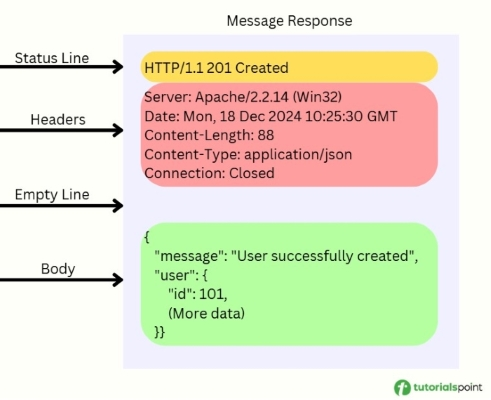

### **Curl**

Чтобы посылать эти запросы "руками", а не через браузер, можно использовать утилиту `curl`. Ей и воспользуемся.

In [ ]:
%%bash
curl example.com/index.html -v

<!doctype html>
<html>
<head>
    <title>Example Domain</title>

    <meta charset="utf-8" />
    <meta http-equiv="Content-type" content="text/html; charset=utf-8" />
    <meta name="viewport" content="width=device-width, initial-scale=1" />
    <style type="text/css">
    body {
        background-color: #f0f0f2;
        margin: 0;
        padding: 0;
        font-family: -apple-system, system-ui, BlinkMacSystemFont, "Segoe UI", "Open Sans", "Helvetica Neue", Helvetica, Arial, sans-serif;
        
    }
    div {
        width: 600px;
        margin: 5em auto;
        padding: 2em;
        background-color: #fdfdff;
        border-radius: 0.5em;
        box-shadow: 2px 3px 7px 2px rgba(0,0,0,0.02);
    }
    a:link, a:visited {
        color: #38488f;
        text-decoration: none;
    }
    @media (max-width: 700px) {
        div {
            margin: 0 auto;
            width: auto;
        }
    }
    </style>    
</head>

<body>
<div>
    <h1>Example Domain</h1>
    <p>This domai

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0*   Trying 23.192.228.80:80...
* Connected to example.com (23.192.228.80) port 80 (#0)
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0> GET /index.html HTTP/1.1
> Host: example.com
> User-Agent: curl/7.81.0
> Accept: */*
> 
* Mark bundle as not supporting multiuse
< HTTP/1.1 200 OK
< Content-Type: text/html
< ETag: "84238dfc8092e5d9c0dac8ef93371a07:1736799080.121134"
< Last-Modified: Mon, 13 Jan 2025 20:11:20 GMT
< Cache-Control: max-age=2611
< Date: Mon, 17 Feb 2025 13:07:13 GMT
< Content-Length: 1256
< Connection: keep-alive
< 
{ [1256 bytes data]
100  1256  100  1256    0     0  28819      0 --:--:-- --:--:-- --:--:-- 28545
* Connection #0 to host example.com left intact


#### Разбор примера

Давайте ещё раз посмотрим на запрос к `example.com/index.html`.

Служебная информация от `curl`:

```
*   Trying 93.184.216.34...
* TCP_NODELAY set
* Connected to example.com (93.184.216.34) port 80 (#0)
```
Запрос клиента:
```
> GET /index.html HTTP/1.1    # Starting line: метод GET, URI -- /index.html, версия протокола -- HTTP/1.1
> Host: example.com           # Заголовки сообщения
> User-Agent: curl/7.58.0
> Accept: */*
>                             # Пустое тело, т.к. мы ничего не передали на сервер.
```

Ответ сервера:
```
< HTTP/1.1 200 OK                          # Starting line: версия протокола и код ответа
< Accept-Ranges: bytes                     # Заголовки ответа
< Age: 482235
< Cache-Control: max-age=6048000            
< Content-Type: text/html; charset=UTF-8
< Date: Wed, 27 Apr 2022 12:33:28 GMT
< Etag: "3147526947+gzip"
< Expires: Wed, 04 May 2022 12:33:28 GMT
< Last-Modified: Thu, 17 Oct 2019 07:18:26 GMT
< Server: ECS (nyb/1D10)
< Vary: Accept-Encoding
< X-Cache: HIT
< Content-Length: 1256
<                                          # Пустая строка -- нужна по стандарту
<!doctype html>                            # Тело ответа -- HTML-документ
<html>
<head>
    <title>Example Domain</title>
. . .
```


# Web scraping

**Веб-скрапинг** - это технология получения веб-данных путем извлечения их со страниц веб-ресурсов.

Состоит из двух этапов:
* Получение html
* Парсинг html

## Получение html



Варианты инструментов:

* `urllib`
* `requests` (de-facto standard)
* `socket` (low-level)

### requests

>HTTP for humans

In [ ]:
import requests

1. Сделаем GET запрос

In [ ]:
response = requests.get('http://example.com')
response

<Response [200]>

2. Посмотрим, какие есть параметры у ответа

In [ ]:
response.url # ссыло4ка

'http://example.com/'

Давайте пройдемся по блоку сожержания "из чего состоит ответ" и попробуем вытащить оттуда информацию

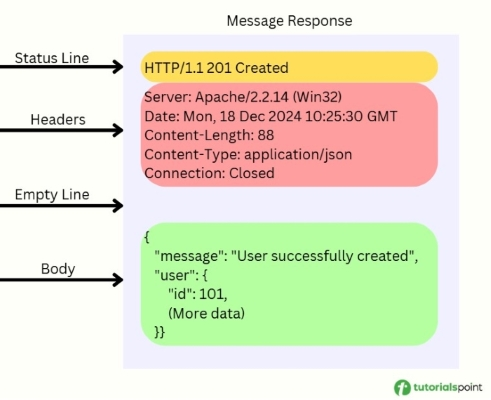

#### Статус

In [ ]:
response.status_code

200

In [ ]:
response.ok

True

#### Хедеры

In [ ]:
response.headers # хедеры

{'Accept-Ranges': 'bytes', 'Content-Type': 'text/html', 'ETag': '"84238dfc8092e5d9c0dac8ef93371a07:1736799080.121134"', 'Last-Modified': 'Mon, 13 Jan 2025 20:11:20 GMT', 'Vary': 'Accept-Encoding', 'Content-Encoding': 'gzip', 'Content-Length': '648', 'Cache-Control': 'max-age=1778', 'Date': 'Mon, 17 Feb 2025 13:07:13 GMT', 'Connection': 'keep-alive'}

#### Тело

In [ ]:
print(response.text)

<!doctype html>
<html>
<head>
    <title>Example Domain</title>

    <meta charset="utf-8" />
    <meta http-equiv="Content-type" content="text/html; charset=utf-8" />
    <meta name="viewport" content="width=device-width, initial-scale=1" />
    <style type="text/css">
    body {
        background-color: #f0f0f2;
        margin: 0;
        padding: 0;
        font-family: -apple-system, system-ui, BlinkMacSystemFont, "Segoe UI", "Open Sans", "Helvetica Neue", Helvetica, Arial, sans-serif;
        
    }
    div {
        width: 600px;
        margin: 5em auto;
        padding: 2em;
        background-color: #fdfdff;
        border-radius: 0.5em;
        box-shadow: 2px 3px 7px 2px rgba(0,0,0,0.02);
    }
    a:link, a:visited {
        color: #38488f;
        text-decoration: none;
    }
    @media (max-width: 700px) {
        div {
            margin: 0 auto;
            width: auto;
        }
    }
    </style>    
</head>

<body>
<div>
    <h1>Example Domain</h1>
    <p>This domai

In [ ]:
response.content

b'<!doctype html>\n<html>\n<head>\n    <title>Example Domain</title>\n\n    <meta charset="utf-8" />\n    <meta http-equiv="Content-type" content="text/html; charset=utf-8" />\n    <meta name="viewport" content="width=device-width, initial-scale=1" />\n    <style type="text/css">\n    body {\n        background-color: #f0f0f2;\n        margin: 0;\n        padding: 0;\n        font-family: -apple-system, system-ui, BlinkMacSystemFont, "Segoe UI", "Open Sans", "Helvetica Neue", Helvetica, Arial, sans-serif;\n        \n    }\n    div {\n        width: 600px;\n        margin: 5em auto;\n        padding: 2em;\n        background-color: #fdfdff;\n        border-radius: 0.5em;\n        box-shadow: 2px 3px 7px 2px rgba(0,0,0,0.02);\n    }\n    a:link, a:visited {\n        color: #38488f;\n        text-decoration: none;\n    }\n    @media (max-width: 700px) {\n        div {\n            margin: 0 auto;\n            width: auto;\n        }\n    }\n    </style>    \n</head>\n\n<body>\n<div>\n    

In [ ]:
response.encoding # кодировка

'ISO-8859-1'

In [ ]:
response.links # ссылки

{}

In [ ]:
type(response.links)

dict

## Парсинг html

**Парсинг** - процесс разбора и систематизации информации и выделения полезных сущностей. **Если простым языком - как вытащить нужную информацию из html**

Популярные инструменты:
* re
* lxml
* BeautifulSoup

In [ ]:
html = requests.get('http://example.com').text
html

'<!doctype html>\n<html>\n<head>\n    <title>Example Domain</title>\n\n    <meta charset="utf-8" />\n    <meta http-equiv="Content-type" content="text/html; charset=utf-8" />\n    <meta name="viewport" content="width=device-width, initial-scale=1" />\n    <style type="text/css">\n    body {\n        background-color: #f0f0f2;\n        margin: 0;\n        padding: 0;\n        font-family: -apple-system, system-ui, BlinkMacSystemFont, "Segoe UI", "Open Sans", "Helvetica Neue", Helvetica, Arial, sans-serif;\n        \n    }\n    div {\n        width: 600px;\n        margin: 5em auto;\n        padding: 2em;\n        background-color: #fdfdff;\n        border-radius: 0.5em;\n        box-shadow: 2px 3px 7px 2px rgba(0,0,0,0.02);\n    }\n    a:link, a:visited {\n        color: #38488f;\n        text-decoration: none;\n    }\n    @media (max-width: 700px) {\n        div {\n            margin: 0 auto;\n            width: auto;\n        }\n    }\n    </style>    \n</head>\n\n<body>\n<div>\n    <

### re

**Регулярные выражения (Regex)** – это строки, задающие шаблон для поиска определенных фрагментов в тексте. Помимо поиска, с помощью специальных Regex-шаблонов можно манипулировать текстовыми фрагментами – удалять и изменять подстроки частично или полностью.

Регулярные выражения состоят из набора литералов (букв и цифр) и метасимволов и выглядят примерно так:

```
r'(https?://)?(www\.)?youtube\.(com|nl)/watch\?v=([\w-]+)(&.*?)?(?=[^-\w&=%])'
```

Используя метасимволы, можно создавать сложные шаблоны, содержащие специальные конструкции для работы с определенными последовательностями и группами символов.

Regex-выражения применяют для обработки текстовых данных, в том числе в скриптах для веб-скрапинга. Кроме того, Regex используют в составе OCR-приложений для очистки отсканированного текста.



#### Регулярные выражения в Python

Для работы с регулярными выражениями в Python имеется модуль `re`.

Для экранирования служебных символов в шаблонах поиска и замены используют два способа – обратный слэш \ и «сырые» строки r''. Второй метод предпочтительнее – он позволяет избежать нагромождения слэшей в шаблонах.

In [ ]:
import re

**Основные функции `re`**

##### match - начало строки

`re.match()` – находит вхождение фрагмента в начале строки. Обычный формат использования – `re.match(r'шаблон', строка)`:

In [ ]:
s = "кутка крякает, кукушка кукует, петух кукарекает"
match = re.match(r'ку', s)
print(match)

<re.Match object; span=(0, 2), match='ку'>


Этот код вернет `None`, несмотря на то, что в строке есть 5 фрагментов «ку». Это происходит потому, что оба фрагмента расположены не в начале строки.

##### search - первое вхождение

`re.search()` – находит первое вхождение фрагмента в любом месте и возвращает объект `match`. Если в строке есть другие фрагменты, соответствующие запросу, `re.search` их проигнорирует. У `re.search` есть дополнительные методы:
- `.span()` – возвращает кортеж, содержащий начальную и конечную позиции искомого фрагмента
- `.string` – вернет строку, переданную в функцию `re.search`
- `.group()` – возвращает фрагмент строки, в котором было обнаружено совпадение

In [ ]:
s = "oт топота копыт пыль по полю летит"
match = re.search(r'по', s)
print(match, match.span(), match.string, match.group(), sep='\n')

<re.Match object; span=(5, 7), match='по'>
(5, 7)
oт топота копыт пыль по полю летит
по


##### findall - все вхождения

`re.findall()` – находит все вхождения фрагмента, в любом месте. Функция `re.findall()` учитывает регистр символов. Чтобы в результат вошли фрагменты с символами в другом регистре, применяют флаг `re.IGNORECASE`:

In [ ]:
s = "Не видно, ликвидны акции или неликвидны."
match = re.findall(r'не', s, re.I)
print(match)

['Не', 'не']


##### split - разбить по шаблону

`re.split()` – расщепляет строку по заданному шаблону. Количество расщеплений задается флагом – в этом примере от строки отделяется только первое слово:

In [ ]:
s = "Обладаешь ли ты налогооблагаемой благодатью?"
res = re.split(r' ', s, 1)
res

['Обладаешь', 'ли ты налогооблагаемой благодатью?']

##### sub - заменить фрагмент

`re.sub()` – заменяет фрагмент в соответствии с шаблоном:

In [ ]:
s = "Коала какао лениво лакала"
res = re.sub(r'коала', 'макака', s)
print(res)

Коала какао лениво лакала


##### compile - создать объект из регулярки

`re.compile()` – создает объект из регулярного выражения. Применяется, если один и тот же поисковый шаблон используется в коде несколько раз:      


In [ ]:
st = re.compile('угнал')
res1 = st.findall("Карл у Клары угнал Maclaren, а Клара у Карла угнала Corvette.")
res2 = st.findall("Карл у Клары угнал кораллы, а Клара у Карла угнала кларнет.")
print(res1, res2, sep='\n')

['угнал', 'угнал']
['угнал', 'угнал']


##### Основные метасимволы в Regex

- `[]`– используется для указания набора или диапазона символов

In [ ]:
re.findall(r'[с-я]', "Камер-юнкер юркнул в бункер", re.I)

['ю', 'ю', 'у', 'у']

In [ ]:
re.findall(r'[аж]', "ажиотаж, мандраж, багаж")

['а', 'ж', 'а', 'ж', 'а', 'а', 'ж', 'а', 'а', 'ж']

- `\` – указывает на начало последовательности (мы рассмотрим их ниже) или экранирует служебные символы
- `.` – выбирает любой символ, кроме новой строки `\n`
- `w` - any word character (буква, цифра или нижнее подчеркивание)
- `^` – проверяет, начинается ли строка с определенного символа / слова / набора символов.

    Например, `r'^Привет'` проверит, начинается ли строка с «Привет».
    
    Метасимвол `^` в наборе `[]` имеет другое значение – проверяет, отсутствуют ли в строке определенные символы (подробнее об этом ниже)
- `$` – проверяет, заканчивается ли строка в соответствии с шаблоном `r'До свиданья.$'`
- `*` – ноль или больше совпадений с шаблоном `r'ко.*аборация'`.
- `+` – одно и более совпадений `r'к.+ператив'`.
- `?` – ноль или одно совпадение `r'ф.?нтастика'`. Кроме того, нейтрализует «жадность» выражений, которые используют `.`, `*`, `+` для выбора любых символов.
- `{}` – точное число совпадений `r'Интерсте.{2}ар'`.
- `|`– любой из двух вариантов `r'уйду|останусь'`.
- `()` – захватывает группу для дальнейших манипуляций – `re.sub(r'(www)', r'\1.', "wwwwear-gear.com")`.
- `<>` – создает именованную группу – `re.search('(?P<группа1>\w+),(?P<группа2>\w+),(?P<группа3>\w+)', 'дом,улица,фонарь')`

#### Регулярки для парсинга

Давайте забудем, что HTML -- дерево, и попробуем попарсить его, как строчку.

In [ ]:
import re

In [ ]:
h1 = re.findall(r'<h1>[\w ]+</h1>', html)

In [ ]:
print(h1)

['<h1>Example Domain</h1>']


In [ ]:
h1 = re.findall(r'<h1>([\w ]+)</h1>', html)

In [ ]:
print(h1)

['Example Domain']


In [ ]:
paragraphs = re.findall(r'<p>(.*)</p>', html)
paragraphs

['<a href="https://www.iana.org/domains/example">More information...</a>']

In [ ]:
print(html)

<!doctype html>
<html>
<head>
    <title>Example Domain</title>

    <meta charset="utf-8" />
    <meta http-equiv="Content-type" content="text/html; charset=utf-8" />
    <meta name="viewport" content="width=device-width, initial-scale=1" />
    <style type="text/css">
    body {
        background-color: #f0f0f2;
        margin: 0;
        padding: 0;
        font-family: -apple-system, system-ui, BlinkMacSystemFont, "Segoe UI", "Open Sans", "Helvetica Neue", Helvetica, Arial, sans-serif;
        
    }
    div {
        width: 600px;
        margin: 5em auto;
        padding: 2em;
        background-color: #fdfdff;
        border-radius: 0.5em;
        box-shadow: 2px 3px 7px 2px rgba(0,0,0,0.02);
    }
    a:link, a:visited {
        color: #38488f;
        text-decoration: none;
    }
    @media (max-width: 700px) {
        div {
            margin: 0 auto;
            width: auto;
        }
    }
    </style>    
</head>

<body>
<div>
    <h1>Example Domain</h1>
    <p>This domai

### BeautifulSoup

Ещё одна библиотека, которая хорошо подходит для парсинга HTML.

1. Импорт

In [ ]:
from bs4 import BeautifulSoup

2. Создадим объект супа

In [ ]:
soup = BeautifulSoup(html, 'lxml')

3. Дальше мы будем ходить по супу и с помощью разных функций вытаскивать узлы дерева

Искать параграфы

In [ ]:
paragraphs = soup.find_all('p')
paragraphs

[<p>This domain is for use in illustrative examples in documents. You may use this
     domain in literature without prior coordination or asking for permission.</p>,
 <p><a href="https://www.iana.org/domains/example">More information...</a></p>]

Искать ссылки

In [ ]:
hrefs = soup.find_all('a')
hrefs

[<a href="https://www.iana.org/domains/example">More information...</a>]

In [ ]:
hrefs = soup.find_all('a', href='https://www.iana.org/domains/example')
hrefs

[<a href="https://www.iana.org/domains/example">More information...</a>]

In [ ]:
hrefs = soup.find_all('a', href='https://www.other-website.org/domains/example')
hrefs

[]

### Пример: парсинг списка страниц при помощи BS4

**Задание:**

Получить *часовые пояса* всех *городов России* из википедии


Давайте попробуем найти страничку, где есть ссылки на все странички городов

In [ ]:
from requests.compat import urljoin, quote_plus, urlparse, unquote

In [ ]:
# список городов России
url = "https://ru.wikipedia.org/wiki/%D0%A1%D0%BF%D0%B8%D1%81%D0%BE%D0%BA_%D0%B3%D0%BE%D1%80%D0%BE%D0%B4%D0%BE%D0%B2_%D0%A0%D0%BE%D1%81%D1%81%D0%B8%D0%B8"

##### Шаг 1: Сделайте GET запрос

HINT: Может понадобиться указать кодировку

In [ ]:
# TODO

##### Шаг 2: Создайте элемент BeautifulSoup

In [ ]:
# TODO

##### Шаг 3: Достаньте все ссылки со странички в список

Hint: Может понадобиться функция `urljoin`

In [ ]:
# TODO

In [ ]:
# TODO

Ура, получили список ссылок на этой страничке! Но не все они - ссылки на города. Часто в таких случаях есть большое количество ненужных ссылок, например, на изображения или ещё куда-то.

##### Шаг 4: Преобразуйте ссылки в читаемый формат

In [ ]:
unquote(links[0])

'https://ru.wikipedia.org/wiki/Список_городов_России'

In [ ]:
# TODO

##### Шаг 5: Напишите функцию фильтрации

In [ ]:
def filter(links, keyword='ru.wikipedia.org/wiki/', stopwords=['Список', 'Файл', 'списки', '2020', '1380', 'Проверка_статей']):
    """ Фильтрует ссылки по ключевым словам и выкидывает те, в которых содержатся стоп-слова

    Args:
        links: list Список ссылок
        keyword: str - ключевое слово в ссылке
        stopwords: list - список слов, которые не должны встречаться в ссылке

    Returns:
       Список из отфильстрованных ссылок

    """
    # TODO

In [ ]:
filtered_links = filter(links)
filtered_links

##### Шаг 6: Проверьте, что ссылки не повторяются

In [ ]:
# TODO

Получается, можем удалить дубликаты и получить уже почти что список городов России

На самом деле, городов России порядка 1150, значит, надо ещё аккуратно посидеть над ссылками, чтобы убрать лишние

##### Шаг 7: Выберите какую-нибудь одну ссылку

In [ ]:
current_link = # TODO

SyntaxError: invalid syntax (<ipython-input-144-3ad4331e3214>, line 1)

In [ ]:
current_link

##### Шаг 8: Сделайте по ней GET запрос

In [ ]:
# TODO

##### Шаг 9: Создайте объект soup

In [ ]:
# TODO

Теперь надо разобраться, как получить из [этой ссылки](https://ru.wikipedia.org/wiki/%D0%90%D0%B1%D0%B0%D0%B7%D0%B0_(%D0%B3%D0%BE%D1%80%D0%BE%D0%B4)) название города и часовой пояс

Давайте изучим ссылку и найдем, где хранится Часовой Пояс

##### Шаг 10: Используя регулярки вытащите часовой пояс

In [ ]:
# TODO

##### Шаг 11: Вытащите название города из ссылки

In [ ]:
# TODO

##### Шаг 11: Запустите цикл по всем ссылкам

In [ ]:
info = []

In [ ]:
# TODO

##### Шаг 12: Соберите всё в пандас

In [ ]:
import pandas as pd

In [ ]:
# TODO

##### Шаг 12: Сохраните в формате csv

In [ ]:
# TODO